# Overview of data
JEPXは翌日の任意の30分間における1kWhの値段を表した時系列データで、未来の需給の期待値となっている。

例えば、3月31日の10:00-10:30の価格は3月30日の午後までに入札がされて決定される

正確な定義
>JEPX価格とは、
前日に行われた入札に基づいて決定される、
翌日の各30分時間帯における
電力1kWhあたりの市場クリアリング価格である。

In [1]:
import sys
from pathlib import Path
# projectルートを追加
sys.path.append(str(Path().resolve().parent))

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import scipy

print("numpy:",np.__version__)
print("pandas:",pd.__version__)
print("matplotlib:",matplotlib.__version__)
print("scipy:",scipy.__version__)

numpy: 2.4.2
pandas: 3.0.1
matplotlib: 3.10.8
scipy: 1.17.1


In [2]:
# 2021〜2024 を結合
dfs = []

for year in range(2021, 2025):
    csv_path = Path(f"../data/raw/spot_summary_{year}.csv")

    df_year = pd.read_csv(csv_path, encoding="cp932")

    # 年度情報を追加
    df_year["year"] = year

    dfs.append(df_year)

# 縦結合
df = pd.concat(dfs, ignore_index=True)

# 確認
print(df.shape)
df.head()

(70128, 20)


,受渡日,時刻コード,売り入札量(kWh),買い入札量(kWh),約定総量(kWh),システムプライス(円/kWh),エリアプライス北海道(円/kWh),エリアプライス東北(円/kWh),エリアプライス東京(円/kWh),エリアプライス中部(円/kWh),エリアプライス北陸(円/kWh),エリアプライス関西(円/kWh),エリアプライス中国(円/kWh),エリアプライス四国(円/kWh),エリアプライス九州(円/kWh),売りブロック入札総量(kWh),売りブロック約定総量(kWh),買いブロック入札総量(kWh),買いブロック約定総量(kWh),year
0,2021/04/01,1,18858000,18427950,15407900,5.63,6.29,6.29,6.29,6.29,6.29,6.29,6.29,6.29,5.63,6444650,3118150,1311300,690100,2021
1,2021/04/01,2,20478700,18642200,15601200,5.63,5.68,5.68,5.68,5.68,5.68,5.68,5.68,5.68,5.63,7948350,3286600,1579900,874050,2021
2,2021/04/01,3,20969850,18695200,15724850,5.49,5.49,5.49,5.49,5.49,5.49,5.49,5.49,5.49,5.49,8382200,3364500,1777050,1071100,2021
3,2021/04/01,4,21238500,18648700,15674700,5.49,5.39,5.39,5.39,5.39,5.39,5.39,5.39,5.39,5.39,8609750,3274500,1826200,1120100,2021
4,2021/04/01,5,21479350,18600100,15639400,5.56,5.56,5.56,5.56,5.56,5.56,5.56,5.56,5.56,5.56,8813050,3195100,1890350,1173200,2021


In [3]:
df.tail()

,受渡日,時刻コード,売り入札量(kWh),買い入札量(kWh),約定総量(kWh),システムプライス(円/kWh),エリアプライス北海道(円/kWh),エリアプライス東北(円/kWh),エリアプライス東京(円/kWh),エリアプライス中部(円/kWh),エリアプライス北陸(円/kWh),エリアプライス関西(円/kWh),エリアプライス中国(円/kWh),エリアプライス四国(円/kWh),エリアプライス九州(円/kWh),売りブロック入札総量(kWh),売りブロック約定総量(kWh),買いブロック入札総量(kWh),買いブロック約定総量(kWh),year
70123,2025/03/31,44,20735800,18888600,14692550,13.78,14.06,14.06,14.06,13.80,13.80,13.80,13.80,8.62,13.80,4731600,697200,1427200,1364700,2024
70124,2025/03/31,45,20233050,19114000,14319300,13.78,14.58,14.58,14.58,14.58,14.58,14.58,14.58,8.65,14.58,4723500,667600,1573100,1417300,2024
70125,2025/03/31,46,20149300,18782600,13947850,13.54,14.09,14.09,14.09,13.70,13.70,13.70,13.70,8.57,13.70,4774950,754000,1374650,1218850,2024
70126,2025/03/31,47,19815900,18495300,13795200,13.49,13.98,13.98,13.98,13.53,13.53,13.53,13.53,8.59,13.53,4654550,738600,1198200,1042600,2024
70127,2025/03/31,48,19737800,17754000,13697150,13.09,13.52,13.52,13.52,12.57,12.57,12.57,12.57,8.57,12.57,4294900,806200,1095700,943450,2024


In [4]:
# 日付をdatetime化
df["受渡日"] = pd.to_datetime(df["受渡日"])

# 時刻コード → 30分刻み
df["datetime"] = (
    df["受渡日"]
    + pd.to_timedelta((df["時刻コード"] - 1) * 30, unit="min")
)

# indexに設定
df = df.set_index("datetime").sort_index()
df.head()

,受渡日,時刻コード,売り入札量(kWh),買い入札量(kWh),約定総量(kWh),システムプライス(円/kWh),エリアプライス北海道(円/kWh),エリアプライス東北(円/kWh),エリアプライス東京(円/kWh),エリアプライス中部(円/kWh),エリアプライス北陸(円/kWh),エリアプライス関西(円/kWh),エリアプライス中国(円/kWh),エリアプライス四国(円/kWh),エリアプライス九州(円/kWh),売りブロック入札総量(kWh),売りブロック約定総量(kWh),買いブロック入札総量(kWh),買いブロック約定総量(kWh),year
datetime,,,,,,,,,,,,,,,,,,,,
2021-04-01 00:00:00,2021-04-01,1,18858000,18427950,15407900,5.63,6.29,6.29,6.29,6.29,6.29,6.29,6.29,6.29,5.63,6444650,3118150,1311300,690100,2021
2021-04-01 00:30:00,2021-04-01,2,20478700,18642200,15601200,5.63,5.68,5.68,5.68,5.68,5.68,5.68,5.68,5.68,5.63,7948350,3286600,1579900,874050,2021
2021-04-01 01:00:00,2021-04-01,3,20969850,18695200,15724850,5.49,5.49,5.49,5.49,5.49,5.49,5.49,5.49,5.49,5.49,8382200,3364500,1777050,1071100,2021
2021-04-01 01:30:00,2021-04-01,4,21238500,18648700,15674700,5.49,5.39,5.39,5.39,5.39,5.39,5.39,5.39,5.39,5.39,8609750,3274500,1826200,1120100,2021
2021-04-01 02:00:00,2021-04-01,5,21479350,18600100,15639400,5.56,5.56,5.56,5.56,5.56,5.56,5.56,5.56,5.56,5.56,8813050,3195100,1890350,1173200,2021


In [5]:
df.tail()

,受渡日,時刻コード,売り入札量(kWh),買い入札量(kWh),約定総量(kWh),システムプライス(円/kWh),エリアプライス北海道(円/kWh),エリアプライス東北(円/kWh),エリアプライス東京(円/kWh),エリアプライス中部(円/kWh),エリアプライス北陸(円/kWh),エリアプライス関西(円/kWh),エリアプライス中国(円/kWh),エリアプライス四国(円/kWh),エリアプライス九州(円/kWh),売りブロック入札総量(kWh),売りブロック約定総量(kWh),買いブロック入札総量(kWh),買いブロック約定総量(kWh),year
datetime,,,,,,,,,,,,,,,,,,,,
2025-03-31 21:30:00,2025-03-31,44,20735800,18888600,14692550,13.78,14.06,14.06,14.06,13.80,13.80,13.80,13.80,8.62,13.80,4731600,697200,1427200,1364700,2024
2025-03-31 22:00:00,2025-03-31,45,20233050,19114000,14319300,13.78,14.58,14.58,14.58,14.58,14.58,14.58,14.58,8.65,14.58,4723500,667600,1573100,1417300,2024
2025-03-31 22:30:00,2025-03-31,46,20149300,18782600,13947850,13.54,14.09,14.09,14.09,13.70,13.70,13.70,13.70,8.57,13.70,4774950,754000,1374650,1218850,2024
2025-03-31 23:00:00,2025-03-31,47,19815900,18495300,13795200,13.49,13.98,13.98,13.98,13.53,13.53,13.53,13.53,8.59,13.53,4654550,738600,1198200,1042600,2024
2025-03-31 23:30:00,2025-03-31,48,19737800,17754000,13697150,13.09,13.52,13.52,13.52,12.57,12.57,12.57,12.57,8.57,12.57,4294900,806200,1095700,943450,2024


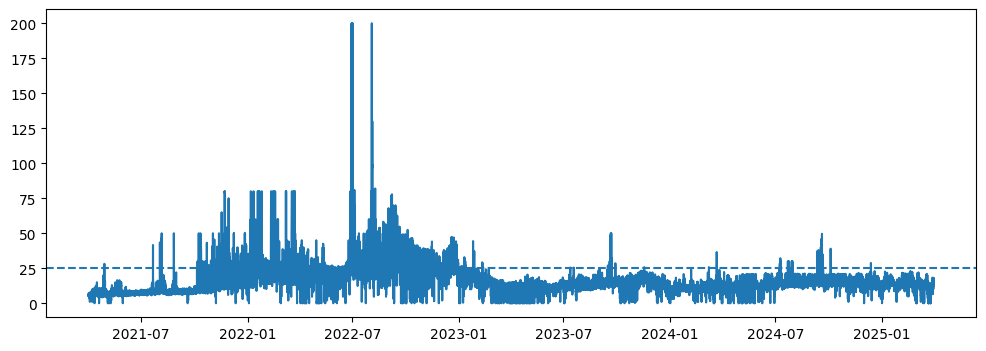

In [6]:
plt.figure(figsize=(12,4))
plt.plot(df["エリアプライス東京(円/kWh)"])
plt.axhline(y=25, linestyle="--")
plt.show()

# Weekly average price distribution

## Base

東京プライスを用いて図1の再現を実施

weekly average price has a left-skewed distribution and is closer to the lognormal distribution

left-skewはおかしいのでright-skewが妥当

In [7]:
price_col = "エリアプライス東京(円/kWh)"

df_base = df[[price_col]].copy()

weekly_base = (
    df_base
    .resample("W")
    .mean()
)
len(weekly_base)

210

In [8]:
weekly_base.skew()
# skew > 0 より、右袖に長い分布ということがわかる

エリアプライス東京(円/kWh)    1.548904
dtype: float64

In [9]:
weekly_base.head()

,エリアプライス東京(円/kWh)
datetime,
2021-04-04,5.795625
2021-04-11,6.433869
2021-04-18,7.525089
2021-04-25,6.892857
2021-05-02,7.954732


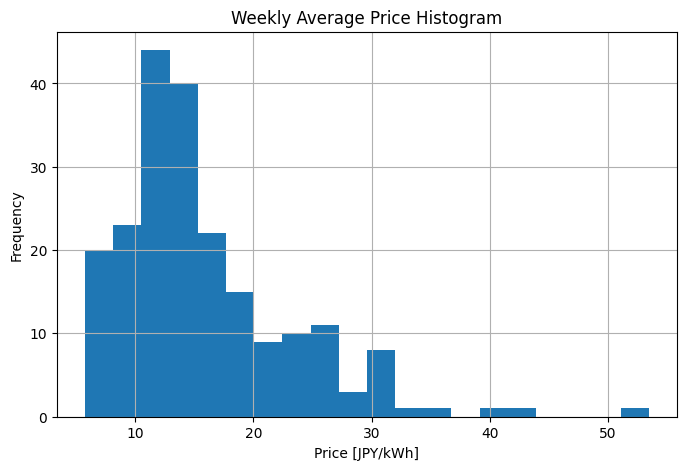

In [10]:
plt.figure(figsize=(8, 5))

plt.hist(
    weekly_base,
    bins=20
)

plt.title("Weekly Average Price Histogram")
plt.xlabel("Price [JPY/kWh]")
plt.ylabel("Frequency")

plt.grid(True)

plt.show()

The weekly average price is closer to the lognormal distribution than the normal distribution

In [11]:
from scipy.stats import norm, lognorm

Normal
mu    = 15.8764
sigma = 7.3248
logLik = -716.1435
AIC    = 1436.2870

Lognormal
shape = 0.4201
loc   = 0.0000
scale = 14.4863
logLik = -677.2269
AIC    = 1358.4538

AICは Lognormal の方が小さいです。対数正規分布の方がよくフィットしています。


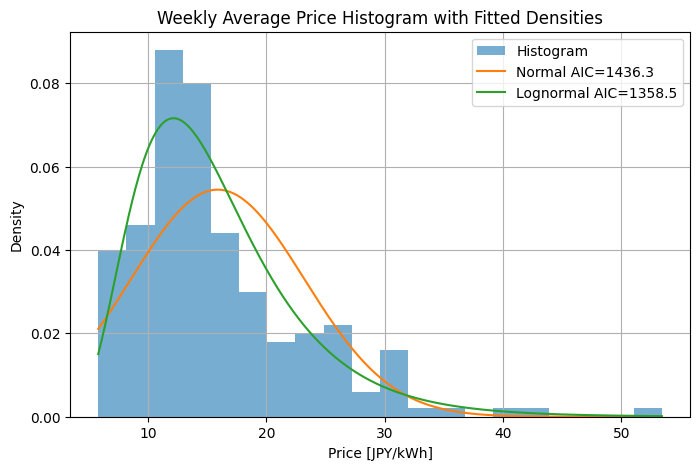

In [12]:
# -----------------------------
# データを1次元配列にする
# -----------------------------
x = weekly_base.squeeze().dropna().values

# 価格は正の値だけ使う
x = x[x > 0]

# -----------------------------
# 1. Normal fit
# -----------------------------
mu_norm, sigma_norm = norm.fit(x)

loglik_norm = np.sum(norm.logpdf(x, loc=mu_norm, scale=sigma_norm))

k_norm = 2  # mu, sigma
aic_norm = 2 * k_norm - 2 * loglik_norm

# -----------------------------
# 2. Lognormal fit
# -----------------------------
shape_lognorm, loc_lognorm, scale_lognorm = lognorm.fit(x, floc=0)

loglik_lognorm = np.sum(
    lognorm.logpdf(
        x,
        s=shape_lognorm,
        loc=loc_lognorm,
        scale=scale_lognorm
    )
)

k_lognorm = 2  # shape, scale。locは floc=0 で固定しているので数えない
aic_lognorm = 2 * k_lognorm - 2 * loglik_lognorm

# -----------------------------
# 3. 結果表示
# -----------------------------
print("Normal")
print(f"mu    = {mu_norm:.4f}")
print(f"sigma = {sigma_norm:.4f}")
print(f"logLik = {loglik_norm:.4f}")
print(f"AIC    = {aic_norm:.4f}")

print()

print("Lognormal")
print(f"shape = {shape_lognorm:.4f}")
print(f"loc   = {loc_lognorm:.4f}")
print(f"scale = {scale_lognorm:.4f}")
print(f"logLik = {loglik_lognorm:.4f}")
print(f"AIC    = {aic_lognorm:.4f}")

print()

if aic_lognorm < aic_norm:
    print("AICは Lognormal の方が小さいです。対数正規分布の方がよくフィットしています。")
else:
    print("AICは Normal の方が小さいです。正規分布の方がよくフィットしています。")

# -----------------------------
# 4. ヒストグラム + fitted density
# -----------------------------
xs = np.linspace(x.min(), x.max(), 500)

pdf_norm = norm.pdf(xs, loc=mu_norm, scale=sigma_norm)

pdf_lognorm = lognorm.pdf(
    xs,
    s=shape_lognorm,
    loc=loc_lognorm,
    scale=scale_lognorm
)

plt.figure(figsize=(8, 5))

plt.hist(
    x,
    bins=20,
    density=True,
    alpha=0.6,
    label="Histogram"
)

plt.plot(
    xs,
    pdf_norm,
    label=f"Normal AIC={aic_norm:.1f}"
)

plt.plot(
    xs,
    pdf_lognorm,
    label=f"Lognormal AIC={aic_lognorm:.1f}"
)

plt.title("Weekly Average Price Histogram with Fitted Densities")
plt.xlabel("Price [JPY/kWh]")
plt.ylabel("Density")
plt.legend()
plt.grid(True)

plt.show()

## Daytime 
日中8:00から18:00に限った話

In [13]:
price_col = "エリアプライス東京(円/kWh)"

# -----------------------------
# daytime data
# 平日 08:00-18:00
# -----------------------------
df_daytime = df[[price_col]].copy()

# 平日だけ
df_daytime = df_daytime[
    df_daytime.index.weekday < 5
]

# 08:00-18:00
df_daytime = df_daytime.between_time(
    "08:00",
    "18:00"
)

# -----------------------------
# weekly average
# -----------------------------
weekly_daytime = (
    df_daytime
    .resample("W")
    .mean()
)

weekly_daytime.head()

,エリアプライス東京(円/kWh)
datetime,
2021-04-04,5.603095
2021-04-11,5.997619
2021-04-18,7.768857
2021-04-25,6.017333
2021-05-02,8.294667


Daytime weekly average price
skewness = 2.4936

Normal
mu     = 17.6192
sigma  = 10.3927
logLik = -789.6093
AIC    = 1583.2186

Lognormal
shape  = 0.4961
loc    = 0.0000
scale  = 15.4545
logLik = -725.7188
AIC    = 1455.4375

AICは Lognormal の方が小さいです。対数正規分布の方がよくフィットしています。


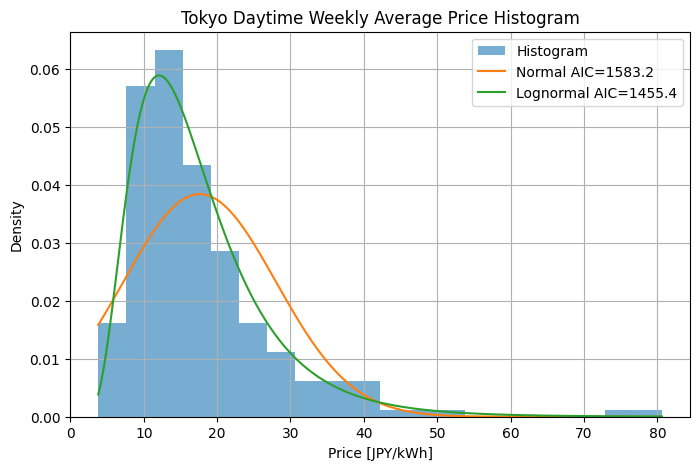

In [14]:
# -----------------------------
# Daytime weekly data
# -----------------------------
x = weekly_daytime.squeeze().dropna().values
x = x[x > 0]

# -----------------------------
# Skewness
# -----------------------------
skew_value = pd.Series(x).skew()

print("Daytime weekly average price")
print(f"skewness = {skew_value:.4f}")

# -----------------------------
# Normal fit
# -----------------------------
mu_norm, sigma_norm = norm.fit(x)
loglik_norm = np.sum(norm.logpdf(x, loc=mu_norm, scale=sigma_norm))

k_norm = 2
aic_norm = 2 * k_norm - 2 * loglik_norm

# -----------------------------
# Lognormal fit
# -----------------------------
shape_lognorm, loc_lognorm, scale_lognorm = lognorm.fit(x, floc=0)

loglik_lognorm = np.sum(
    lognorm.logpdf(
        x,
        s=shape_lognorm,
        loc=loc_lognorm,
        scale=scale_lognorm
    )
)

k_lognorm = 2
aic_lognorm = 2 * k_lognorm - 2 * loglik_lognorm

# -----------------------------
# Result
# -----------------------------
print()
print("Normal")
print(f"mu     = {mu_norm:.4f}")
print(f"sigma  = {sigma_norm:.4f}")
print(f"logLik = {loglik_norm:.4f}")
print(f"AIC    = {aic_norm:.4f}")

print()
print("Lognormal")
print(f"shape  = {shape_lognorm:.4f}")
print(f"loc    = {loc_lognorm:.4f}")
print(f"scale  = {scale_lognorm:.4f}")
print(f"logLik = {loglik_lognorm:.4f}")
print(f"AIC    = {aic_lognorm:.4f}")

print()
if aic_lognorm < aic_norm:
    print("AICは Lognormal の方が小さいです。対数正規分布の方がよくフィットしています。")
else:
    print("AICは Normal の方が小さいです。正規分布の方がよくフィットしています。")

# -----------------------------
# Plot
# -----------------------------
xs = np.linspace(x.min(), x.max(), 500)

pdf_norm = norm.pdf(xs, loc=mu_norm, scale=sigma_norm)

pdf_lognorm = lognorm.pdf(
    xs,
    s=shape_lognorm,
    loc=loc_lognorm,
    scale=scale_lognorm
)

plt.figure(figsize=(8, 5))

plt.hist(
    x,
    bins=20,
    density=True,
    alpha=0.6,
    label="Histogram"
)

plt.plot(
    xs,
    pdf_norm,
    label=f"Normal AIC={aic_norm:.1f}"
)

plt.plot(
    xs,
    pdf_lognorm,
    label=f"Lognormal AIC={aic_lognorm:.1f}"
)

plt.title("Tokyo Daytime Weekly Average Price Histogram")
plt.xlabel("Price [JPY/kWh]")
plt.ylabel("Density")
plt.legend()
plt.grid(True)

plt.show()

そもそもだが2022年は別市場に見えるくらい価格の変化が激しい

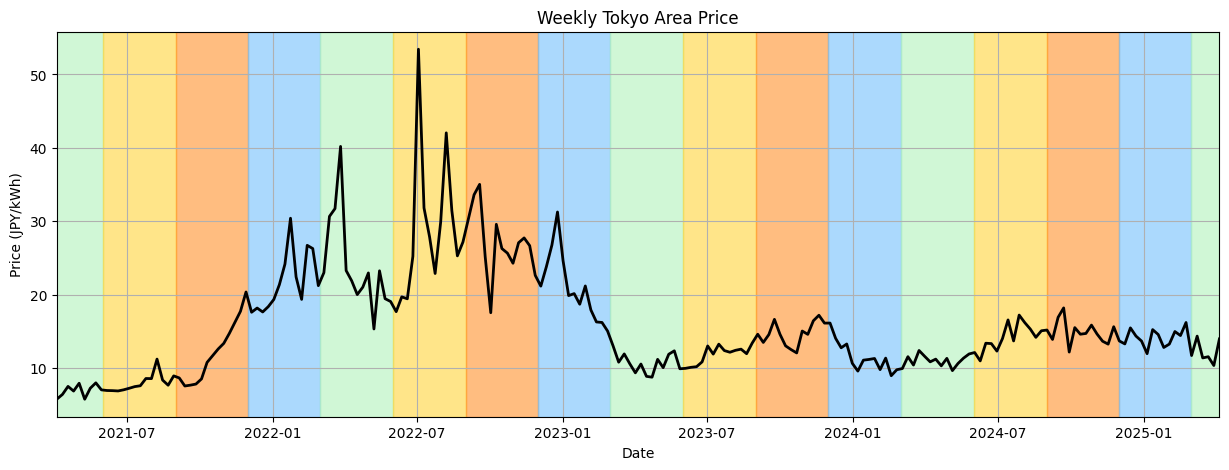

In [15]:
# 時系列プロット
fig, ax = plt.subplots(figsize=(15, 5))

season_colors = {
    "spring": "#b2f2bb",  # 黄緑
    "summer": "#ffd43b",  # 黄色
    "autumn": "#ff922b",  # オレンジ
    "winter": "#74c0fc",  # 水色
}

years = range(
    weekly_base.index.min().year,
    weekly_base.index.max().year + 1
)

for year in years:

    seasons = [
        ("spring", f"{year}-03-01", f"{year}-06-01"),
        ("summer", f"{year}-06-01", f"{year}-09-01"),
        ("autumn", f"{year}-09-01", f"{year}-12-01"),
        ("winter", f"{year}-12-01", f"{year+1}-03-01"),
    ]

    for season, start, end in seasons:
        ax.axvspan(
            pd.to_datetime(start),
            pd.to_datetime(end),
            color=season_colors[season],
            alpha=0.6
        )

# 折れ線
ax.plot(
    weekly_base.index,
    weekly_base["エリアプライス東京(円/kWh)"],
    linewidth=2,
    color="black"
)

# データ範囲に合わせる
ax.set_xlim(
    weekly_base.index.min(),
    weekly_base.index.max()
)

ax.set_title("Weekly Tokyo Area Price")
ax.set_xlabel("Date")
ax.set_ylabel("Price (JPY/kWh)")
ax.grid(True)

plt.show()

# 論文のデータ範囲に合わせる

In [16]:
dfs = []

for year in range(2016, 2020):
    csv_path = Path(f"../data/raw/spot_summary_{year}.csv")

    df_year = pd.read_csv(csv_path, encoding="cp932")

    # 年度情報を追加
    df_year["year"] = year

    dfs.append(df_year)

# 縦結合
df = pd.concat(dfs, ignore_index=True)

# 確認
print(df.shape)
df.head()

(70128, 20)


,受渡日,時刻コード,売り入札量(kWh),買い入札量(kWh),約定総量(kWh),システムプライス(円/kWh),エリアプライス北海道(円/kWh),エリアプライス東北(円/kWh),エリアプライス東京(円/kWh),エリアプライス中部(円/kWh),エリアプライス北陸(円/kWh),エリアプライス関西(円/kWh),エリアプライス中国(円/kWh),エリアプライス四国(円/kWh),エリアプライス九州(円/kWh),売りブロック入札総量(kWh),売りブロック約定総量(kWh),買いブロック入札総量(kWh),買いブロック約定総量(kWh),year
0,2016/04/01,1,5077000,2120500,675500,6.61,8.66,6.69,6.69,6.69,6.69,6.69,6.69,6.69,4.00,1665000,45000,NaN,NaN,2016
1,2016/04/01,2,5621500,2239000,755500,6.34,8.66,6.34,6.34,6.34,6.34,6.34,6.34,6.34,4.00,1979000,195000,NaN,NaN,2016
2,2016/04/01,3,5710500,2219000,713500,6.34,7.20,6.34,6.34,6.34,6.34,6.34,6.34,6.34,4.00,2236500,195000,NaN,NaN,2016
3,2016/04/01,4,5536000,2202500,717500,6.25,7.10,6.03,6.03,6.03,6.03,6.03,6.03,6.03,4.00,2236500,195000,NaN,NaN,2016
4,2016/04/01,5,5461000,2192000,870500,6.57,7.10,6.57,6.57,6.57,6.57,6.57,6.57,6.57,5.28,2191500,170000,NaN,NaN,2016


In [17]:
# 日付をdatetime化
df["受渡日"] = pd.to_datetime(df["受渡日"])

# 時刻コード → 30分刻み
df["datetime"] = (
    df["受渡日"]
    + pd.to_timedelta((df["時刻コード"] - 1) * 30, unit="min")
)

# indexに設定
df = df.set_index("datetime").sort_index()
df.head()

,受渡日,時刻コード,売り入札量(kWh),買い入札量(kWh),約定総量(kWh),システムプライス(円/kWh),エリアプライス北海道(円/kWh),エリアプライス東北(円/kWh),エリアプライス東京(円/kWh),エリアプライス中部(円/kWh),エリアプライス北陸(円/kWh),エリアプライス関西(円/kWh),エリアプライス中国(円/kWh),エリアプライス四国(円/kWh),エリアプライス九州(円/kWh),売りブロック入札総量(kWh),売りブロック約定総量(kWh),買いブロック入札総量(kWh),買いブロック約定総量(kWh),year
datetime,,,,,,,,,,,,,,,,,,,,
2016-04-01 00:00:00,2016-04-01,1,5077000,2120500,675500,6.61,8.66,6.69,6.69,6.69,6.69,6.69,6.69,6.69,4.00,1665000,45000,NaN,NaN,2016
2016-04-01 00:30:00,2016-04-01,2,5621500,2239000,755500,6.34,8.66,6.34,6.34,6.34,6.34,6.34,6.34,6.34,4.00,1979000,195000,NaN,NaN,2016
2016-04-01 01:00:00,2016-04-01,3,5710500,2219000,713500,6.34,7.20,6.34,6.34,6.34,6.34,6.34,6.34,6.34,4.00,2236500,195000,NaN,NaN,2016
2016-04-01 01:30:00,2016-04-01,4,5536000,2202500,717500,6.25,7.10,6.03,6.03,6.03,6.03,6.03,6.03,6.03,4.00,2236500,195000,NaN,NaN,2016
2016-04-01 02:00:00,2016-04-01,5,5461000,2192000,870500,6.57,7.10,6.57,6.57,6.57,6.57,6.57,6.57,6.57,5.28,2191500,170000,NaN,NaN,2016


In [18]:
df.tail()

,受渡日,時刻コード,売り入札量(kWh),買い入札量(kWh),約定総量(kWh),システムプライス(円/kWh),エリアプライス北海道(円/kWh),エリアプライス東北(円/kWh),エリアプライス東京(円/kWh),エリアプライス中部(円/kWh),エリアプライス北陸(円/kWh),エリアプライス関西(円/kWh),エリアプライス中国(円/kWh),エリアプライス四国(円/kWh),エリアプライス九州(円/kWh),売りブロック入札総量(kWh),売りブロック約定総量(kWh),買いブロック入札総量(kWh),買いブロック約定総量(kWh),year
datetime,,,,,,,,,,,,,,,,,,,,
2020-03-31 21:30:00,2020-03-31,44,20697600,20882750,17212050,5.16,35.05,8.91,8.91,4.48,4.48,4.48,4.48,4.48,4.48,6898150,4303350,3752750.0,3402750.0,2019
2020-03-31 22:00:00,2020-03-31,45,20013150,20889400,16410100,6.40,14.00,8.76,8.76,4.49,4.49,4.49,4.49,4.49,4.49,6549350,4259350,3705750.0,3355750.0,2019
2020-03-31 22:30:00,2020-03-31,46,19464200,20109350,16032350,6.44,14.00,8.52,8.52,4.42,4.42,4.42,4.42,4.42,4.42,6192700,4165200,3237000.0,2987000.0,2019
2020-03-31 23:00:00,2020-03-31,47,18820100,19344650,15681950,6.46,15.00,7.06,7.06,4.47,4.47,4.47,4.47,4.47,4.47,5577900,3914900,2747500.0,2597500.0,2019
2020-03-31 23:30:00,2020-03-31,48,18148300,18256100,15216300,6.35,14.00,6.85,6.85,4.27,4.27,4.27,4.27,4.27,4.27,5142150,3736150,2162800.0,2112800.0,2019


In [19]:
price_col = "エリアプライス東京(円/kWh)"

df_base = df[[price_col]].copy()

weekly_base = (
    df_base
    .resample("W")
    .mean()
)
len(weekly_base)

210

エリアプライス東京(円/kWh)    1.794415
dtype: float64
Normal
mu    = 9.8045
sigma = 1.9848
logLik = -441.9389
AIC    = 887.8779

Lognormal
shape = 0.1810
loc   = 0.0000
scale = 9.6341
logLik = -414.7969
AIC    = 833.5939

AICは Lognormal の方が小さいです。対数正規分布の方がよくフィットしています。


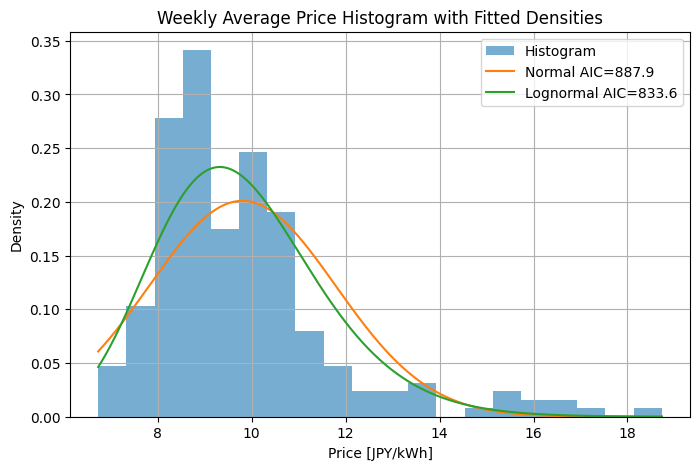

In [20]:
print(weekly_base.skew())

# -----------------------------
# データを1次元配列にする
# -----------------------------
x = weekly_base.squeeze().dropna().values

# 価格は正の値だけ使う
x = x[x > 0]

# -----------------------------
# 1. Normal fit
# -----------------------------
mu_norm, sigma_norm = norm.fit(x)

loglik_norm = np.sum(norm.logpdf(x, loc=mu_norm, scale=sigma_norm))

k_norm = 2  # mu, sigma
aic_norm = 2 * k_norm - 2 * loglik_norm

# -----------------------------
# 2. Lognormal fit
# -----------------------------
shape_lognorm, loc_lognorm, scale_lognorm = lognorm.fit(x, floc=0)

loglik_lognorm = np.sum(
    lognorm.logpdf(
        x,
        s=shape_lognorm,
        loc=loc_lognorm,
        scale=scale_lognorm
    )
)

k_lognorm = 2  # shape, scale。locは floc=0 で固定しているので数えない
aic_lognorm = 2 * k_lognorm - 2 * loglik_lognorm

# -----------------------------
# 3. 結果表示
# -----------------------------
print("Normal")
print(f"mu    = {mu_norm:.4f}")
print(f"sigma = {sigma_norm:.4f}")
print(f"logLik = {loglik_norm:.4f}")
print(f"AIC    = {aic_norm:.4f}")

print()

print("Lognormal")
print(f"shape = {shape_lognorm:.4f}")
print(f"loc   = {loc_lognorm:.4f}")
print(f"scale = {scale_lognorm:.4f}")
print(f"logLik = {loglik_lognorm:.4f}")
print(f"AIC    = {aic_lognorm:.4f}")

print()

if aic_lognorm < aic_norm:
    print("AICは Lognormal の方が小さいです。対数正規分布の方がよくフィットしています。")
else:
    print("AICは Normal の方が小さいです。正規分布の方がよくフィットしています。")

# -----------------------------
# 4. ヒストグラム + fitted density
# -----------------------------
xs = np.linspace(x.min(), x.max(), 500)

pdf_norm = norm.pdf(xs, loc=mu_norm, scale=sigma_norm)

pdf_lognorm = lognorm.pdf(
    xs,
    s=shape_lognorm,
    loc=loc_lognorm,
    scale=scale_lognorm
)

plt.figure(figsize=(8, 5))

plt.hist(
    x,
    bins=20,
    density=True,
    alpha=0.6,
    label="Histogram"
)

plt.plot(
    xs,
    pdf_norm,
    label=f"Normal AIC={aic_norm:.1f}"
)

plt.plot(
    xs,
    pdf_lognorm,
    label=f"Lognormal AIC={aic_lognorm:.1f}"
)

plt.title("Weekly Average Price Histogram with Fitted Densities")
plt.xlabel("Price [JPY/kWh]")
plt.ylabel("Density")
plt.legend()
plt.grid(True)

plt.show()


In [21]:
price_col = "エリアプライス東京(円/kWh)"

# -----------------------------
# daytime data
# 平日 08:00-18:00
# -----------------------------
df_daytime = df[[price_col]].copy()

# 平日だけ
df_daytime = df_daytime[
    df_daytime.index.weekday < 5
]

# 08:00-18:00
df_daytime = df_daytime.between_time(
    "08:00",
    "18:00"
)

# -----------------------------
# weekly average
# -----------------------------
weekly_daytime = (
    df_daytime
    .resample("W")
    .mean()
)

weekly_daytime.head()

,エリアプライス東京(円/kWh)
datetime,
2016-04-03,9.380952
2016-04-10,8.811333
2016-04-17,9.627619
2016-04-24,9.952667
2016-05-01,16.528476


Daytime weekly average price
skewness = 2.0805

Normal
mu     = 11.7166
sigma  = 3.7156
logLik = -573.6096
AIC    = 1151.2191

Lognormal
shape  = 0.2698
loc    = 0.0000
scale  = 11.2580
logLik = -531.2888
AIC    = 1066.5776

AICは Lognormal の方が小さいです。対数正規分布の方がよくフィットしています。


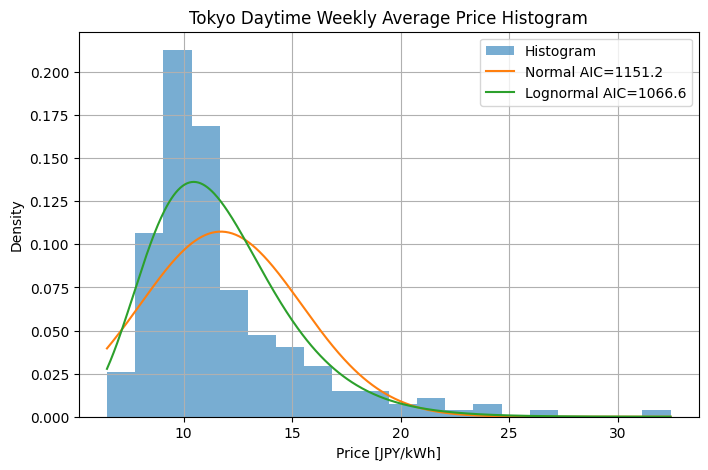

In [22]:
# -----------------------------
# Daytime weekly data
# -----------------------------
x = weekly_daytime.squeeze().dropna().values
x = x[x > 0]

# -----------------------------
# Skewness
# -----------------------------
skew_value = pd.Series(x).skew()

print("Daytime weekly average price")
print(f"skewness = {skew_value:.4f}")

# -----------------------------
# Normal fit
# -----------------------------
mu_norm, sigma_norm = norm.fit(x)
loglik_norm = np.sum(norm.logpdf(x, loc=mu_norm, scale=sigma_norm))

k_norm = 2
aic_norm = 2 * k_norm - 2 * loglik_norm

# -----------------------------
# Lognormal fit
# -----------------------------
shape_lognorm, loc_lognorm, scale_lognorm = lognorm.fit(x, floc=0)

loglik_lognorm = np.sum(
    lognorm.logpdf(
        x,
        s=shape_lognorm,
        loc=loc_lognorm,
        scale=scale_lognorm
    )
)

k_lognorm = 2
aic_lognorm = 2 * k_lognorm - 2 * loglik_lognorm

# -----------------------------
# Result
# -----------------------------
print()
print("Normal")
print(f"mu     = {mu_norm:.4f}")
print(f"sigma  = {sigma_norm:.4f}")
print(f"logLik = {loglik_norm:.4f}")
print(f"AIC    = {aic_norm:.4f}")

print()
print("Lognormal")
print(f"shape  = {shape_lognorm:.4f}")
print(f"loc    = {loc_lognorm:.4f}")
print(f"scale  = {scale_lognorm:.4f}")
print(f"logLik = {loglik_lognorm:.4f}")
print(f"AIC    = {aic_lognorm:.4f}")

print()
if aic_lognorm < aic_norm:
    print("AICは Lognormal の方が小さいです。対数正規分布の方がよくフィットしています。")
else:
    print("AICは Normal の方が小さいです。正規分布の方がよくフィットしています。")

# -----------------------------
# Plot
# -----------------------------
xs = np.linspace(x.min(), x.max(), 500)

pdf_norm = norm.pdf(xs, loc=mu_norm, scale=sigma_norm)

pdf_lognorm = lognorm.pdf(
    xs,
    s=shape_lognorm,
    loc=loc_lognorm,
    scale=scale_lognorm
)

plt.figure(figsize=(8, 5))

plt.hist(
    x,
    bins=20,
    density=True,
    alpha=0.6,
    label="Histogram"
)

plt.plot(
    xs,
    pdf_norm,
    label=f"Normal AIC={aic_norm:.1f}"
)

plt.plot(
    xs,
    pdf_lognorm,
    label=f"Lognormal AIC={aic_lognorm:.1f}"
)

plt.title("Tokyo Daytime Weekly Average Price Histogram")
plt.xlabel("Price [JPY/kWh]")
plt.ylabel("Density")
plt.legend()
plt.grid(True)

plt.show()

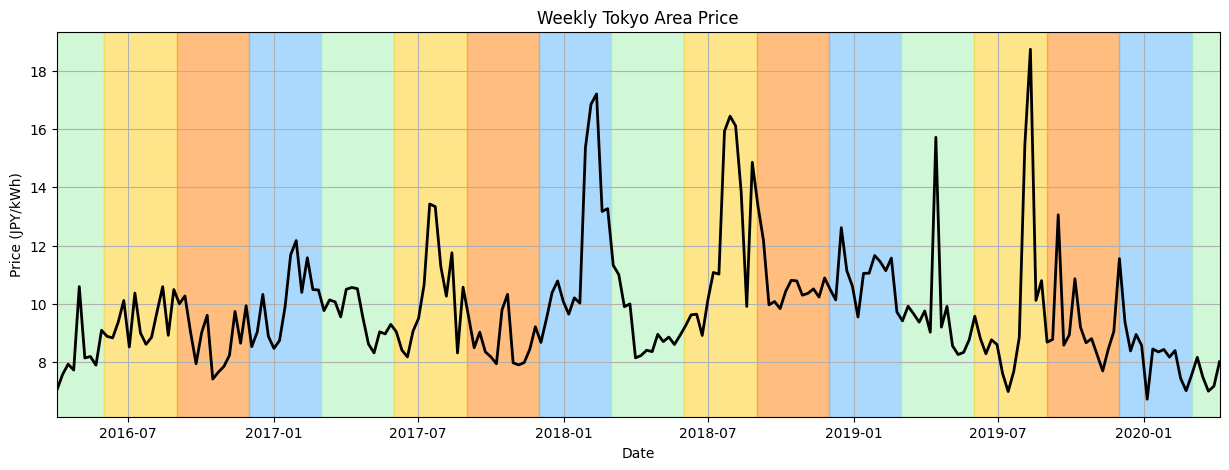

In [23]:
# 時系列プロット
fig, ax = plt.subplots(figsize=(15, 5))

season_colors = {
    "spring": "#b2f2bb",  # 黄緑
    "summer": "#ffd43b",  # 黄色
    "autumn": "#ff922b",  # オレンジ
    "winter": "#74c0fc",  # 水色
}

years = range(
    weekly_base.index.min().year,
    weekly_base.index.max().year + 1
)

for year in years:

    seasons = [
        ("spring", f"{year}-03-01", f"{year}-06-01"),
        ("summer", f"{year}-06-01", f"{year}-09-01"),
        ("autumn", f"{year}-09-01", f"{year}-12-01"),
        ("winter", f"{year}-12-01", f"{year+1}-03-01"),
    ]

    for season, start, end in seasons:
        ax.axvspan(
            pd.to_datetime(start),
            pd.to_datetime(end),
            color=season_colors[season],
            alpha=0.6
        )

# 折れ線
ax.plot(
    weekly_base.index,
    weekly_base["エリアプライス東京(円/kWh)"],
    linewidth=2,
    color="black"
)

# データ範囲に合わせる
ax.set_xlim(
    weekly_base.index.min(),
    weekly_base.index.max()
)

ax.set_title("Weekly Tokyo Area Price")
ax.set_xlabel("Date")
ax.set_ylabel("Price (JPY/kWh)")
ax.grid(True)

plt.show()

In [26]:
weekly_base = weekly_base.rename(
    columns={
        "エリアプライス東京(円/kWh)": "tokyo_price"
    }
)

weekly_base.head()

,tokyo_price
datetime,
2016-04-03,7.061875
2016-04-10,7.583363
2016-04-17,7.936190
2016-04-24,7.734077
2016-05-01,10.593512


In [27]:
weekly_daytime = weekly_daytime.rename(
    columns={
        "エリアプライス東京(円/kWh)": "tokyo_price"
    }
)
weekly_daytime.head()

,tokyo_price
datetime,
2016-04-03,9.380952
2016-04-10,8.811333
2016-04-17,9.627619
2016-04-24,9.952667
2016-05-01,16.528476


In [30]:
# 保存先
output_path = Path("../data/processed/weekly_base.csv")

# ディレクトリがなければ作成
output_path.parent.mkdir(parents=True, exist_ok=True)

# CSV出力
weekly_base.to_csv(output_path, encoding="utf-8-sig")

print(f"saved: {output_path}")

saved: ..\data\processed\weekly_base.csv


In [31]:
# 保存先
output_path = Path("../data/processed/weekly_daytime.csv")

# ディレクトリがなければ作成
output_path.parent.mkdir(parents=True, exist_ok=True)

# CSV出力
weekly_daytime.to_csv(output_path, encoding="utf-8-sig")

print(f"saved: {output_path}")

saved: ..\data\processed\weekly_daytime.csv
